In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data  = pd.read_csv("C:/Users/Om/Downloads/insurance.csv")

# EDA

In [3]:
data.shape

(1338, 7)

In [4]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Data Cleaning

In [9]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Handling Duplicates

In [10]:
data.duplicated().sum()

np.int64(1)

In [11]:
data.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Univariate Analysis

In [12]:
data['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

<Axes: ylabel='Density'>

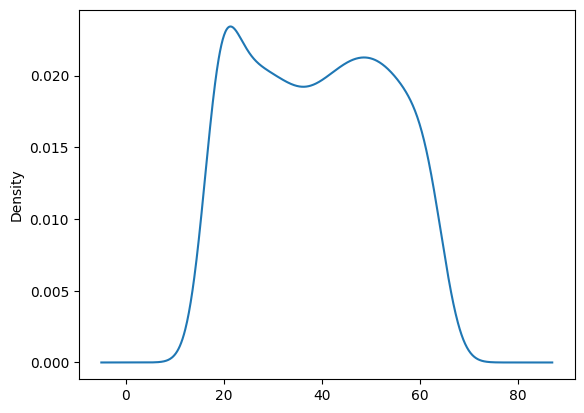

In [13]:
data['age'].plot(kind = 'kde')

<Axes: xlabel='smoker', ylabel='count'>

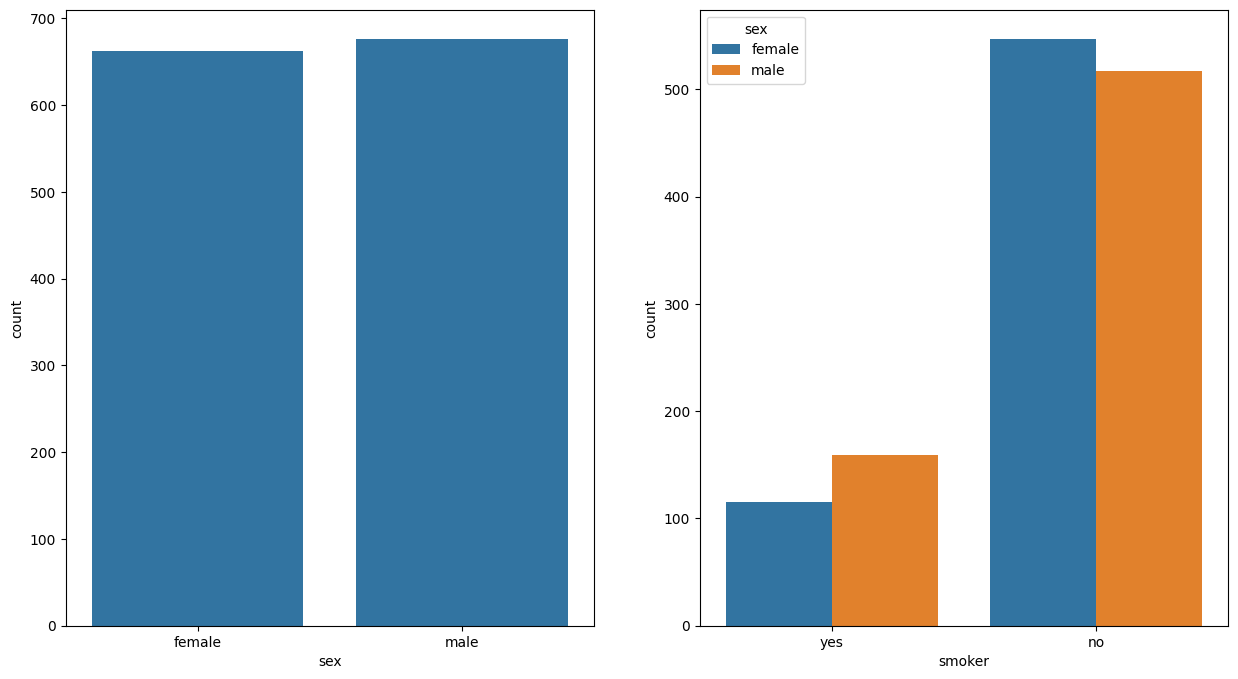

In [14]:
plt.figure(figsize = (15,8))
plt.subplot(1,2,1)
sns.countplot(x = data['sex'], data = data)

plt.subplot(1,2,2)
sns.countplot(x = data['smoker'], data = data, hue = data['sex'])

<Axes: xlabel='region', ylabel='count'>

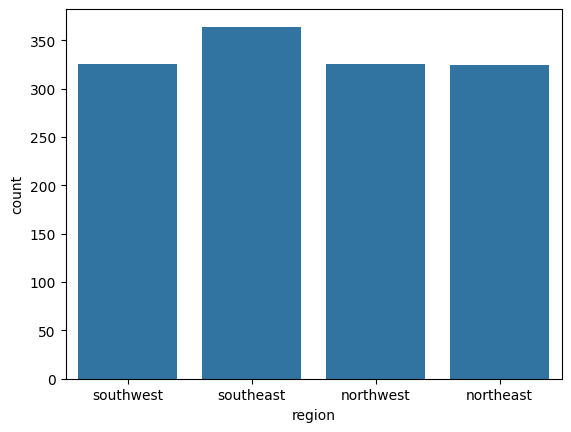

In [15]:
sns.countplot(x = data['region'], data = data)

<Axes: xlabel='children'>

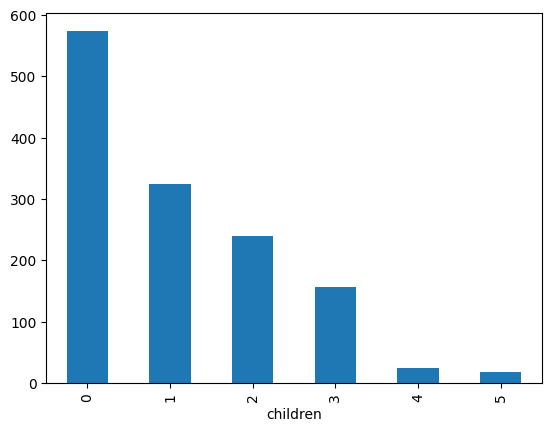

In [16]:
data['children'].value_counts().plot(kind = 'bar')

# Outlier Detection

<Axes: ylabel='bmi'>

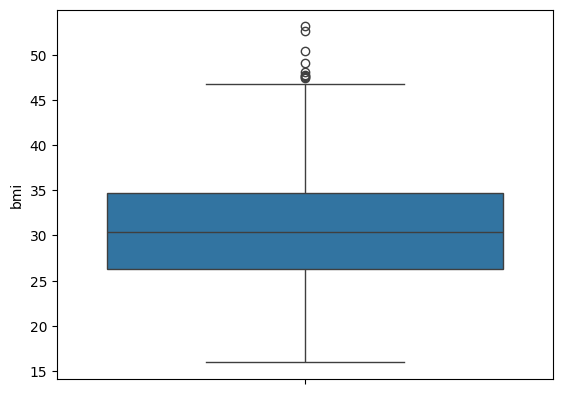

In [17]:
sns.boxplot(data['bmi'])

# Bivariate Analysis

In [18]:
data.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: xlabel='age', ylabel='bmi'>

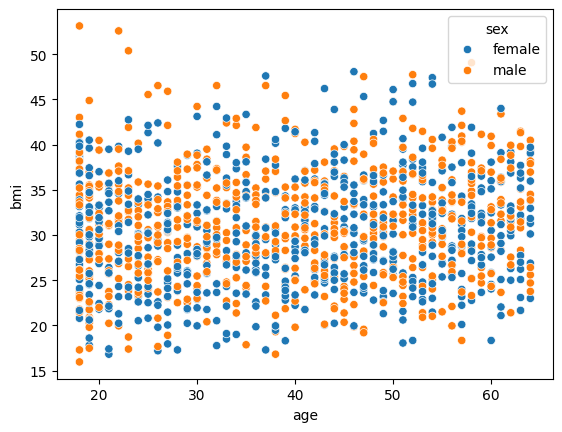

In [19]:
sns.scatterplot(x = 'age', y= 'bmi', data = data, hue = 'sex')

<Axes: xlabel='charges', ylabel='bmi'>

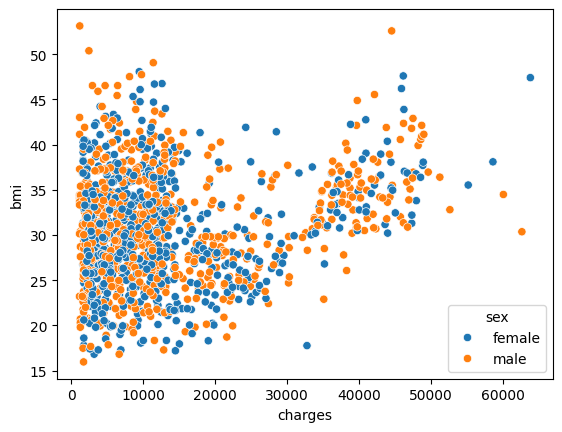

In [20]:
sns.scatterplot(x = 'charges', y= 'bmi', data = data, hue = 'sex')

In [21]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='region', ylabel='count'>

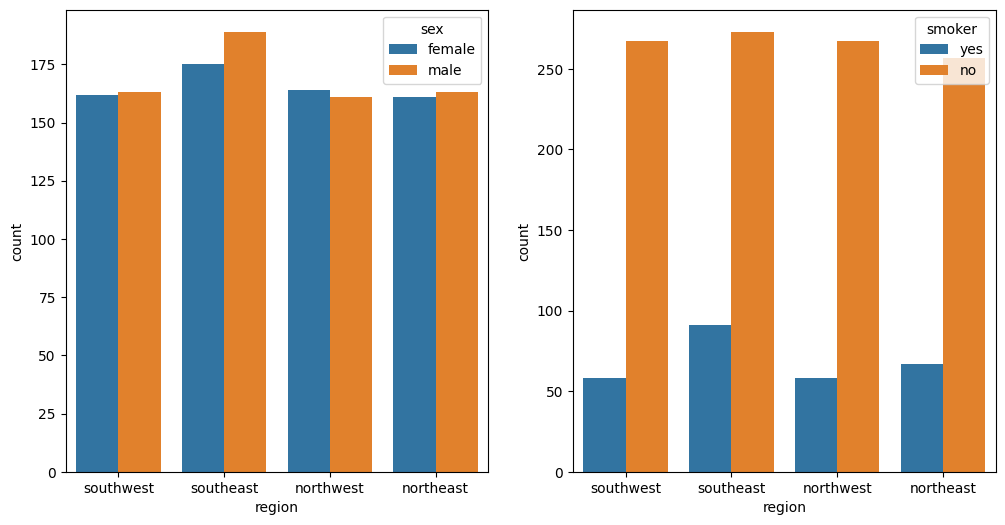

In [22]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
sns.countplot(x = data['region'], hue = data['sex'])

plt.subplot(1,2,2)
sns.countplot(x = data['region'], hue = data['smoker'])

In [23]:
pd.crosstab(data['sex'], data['region'])

region,northeast,northwest,southeast,southwest
sex,,,,
female,161,164,175,162
male,163,161,189,163


In [24]:
pd.crosstab(data['smoker'], data['region'])

region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,267,273,267
yes,67,58,91,58


# Correlation Analysis

<Axes: >

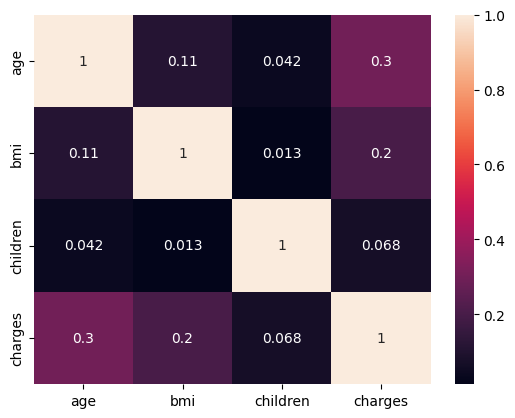

In [25]:
sns.heatmap(data.corr(numeric_only = True), annot = True)

# Feature Engineering

In [26]:
data.replace({"female":"F","male":"M"})

,age,sex,bmi,children,smoker,region,charges
0,19,F,27.900,0,yes,southwest,16884.92400
1,18,M,33.770,1,no,southeast,1725.55230
2,28,M,33.000,3,no,southeast,4449.46200
3,33,M,22.705,0,no,northwest,21984.47061
4,32,M,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,M,30.970,3,no,northwest,10600.54830
1334,18,F,31.920,0,no,northeast,2205.98080
1335,18,F,36.850,0,no,southeast,1629.83350
1336,21,F,25.800,0,no,southwest,2007.94500


In [27]:
data['bmi'].dtype

dtype('float64')

In [28]:
data['bmi'] = data['bmi'].astype(int)

In [29]:
data['bmi_category'] = data['bmi'].apply(
    lambda x:
    'Under Weight' if x < 18.5 else
    'Healthy Weight' if 18.5 <= x < 24.9 else
    'Over Weight' if 25 <= x < 29.9 else
    'Obese' if 30 <= x < 34.9 else
    'Heavy Obese' if 35 <= x < 39.9 else
    'Morbidly Obese'
)

In [30]:
data.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27,0,yes,southwest,16884.92400,Over Weight
1,18,male,33,1,no,southeast,1725.55230,Obese
2,28,male,33,3,no,southeast,4449.46200,Obese
3,33,male,22,0,no,northwest,21984.47061,Healthy Weight
4,32,male,28,0,no,northwest,3866.85520,Over Weight


# Feature Transformation

In [31]:
data = data.replace({'female':0,'male':1})

C:\Users\Om\AppData\Local\Temp\ipykernel_17040\1614805827.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'female':0,'male':1})


In [32]:
data = data.replace({'yes':0,'no':1})

C:\Users\Om\AppData\Local\Temp\ipykernel_17040\2223458858.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'yes':0,'no':1})


In [33]:
data = pd.get_dummies(data, columns = ['region'], dtype = int)

In [34]:
data = pd.get_dummies(data, columns = ['bmi_category'], dtype = int)

In [35]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Healthy Weight,bmi_category_Heavy Obese,bmi_category_Morbidly Obese,bmi_category_Obese,bmi_category_Over Weight,bmi_category_Under Weight
0,19,0,27,0,0,16884.92400,0,0,0,1,0,0,0,0,1,0
1,18,1,33,1,1,1725.55230,0,0,1,0,0,0,0,1,0,0
2,28,1,33,3,1,4449.46200,0,0,1,0,0,0,0,1,0,0
3,33,1,22,0,1,21984.47061,0,1,0,0,1,0,0,0,0,0
4,32,1,28,0,1,3866.85520,0,1,0,0,0,0,0,0,1,0


# Feature Scalling

In [36]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

# Scale columns
data[['age', 'bmi', 'children']] = scaler.fit_transform(
    data[['age', 'bmi', 'children']]
)

In [37]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Healthy Weight,bmi_category_Heavy Obese,bmi_category_Morbidly Obese,bmi_category_Obese,bmi_category_Over Weight,bmi_category_Under Weight
0,0.021739,0,0.315789,0.0,0,16884.92400,0,0,0,1,0,0,0,0,1,0
1,0.000000,1,0.473684,0.2,1,1725.55230,0,0,1,0,0,0,0,1,0,0
2,0.217391,1,0.473684,0.6,1,4449.46200,0,0,1,0,0,0,0,1,0,0
3,0.326087,1,0.184211,0.0,1,21984.47061,0,1,0,0,1,0,0,0,0,0
4,0.304348,1,0.342105,0.0,1,3866.85520,0,1,0,0,0,0,0,0,1,0


# Train Test Split

In [39]:
X = data.drop(['charges'], axis = 1)
y = data[['charges']]

In [40]:
X.head(5)

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Healthy Weight,bmi_category_Heavy Obese,bmi_category_Morbidly Obese,bmi_category_Obese,bmi_category_Over Weight,bmi_category_Under Weight
0,0.021739,0,0.315789,0.0,0,0,0,0,1,0,0,0,0,1,0
1,0.000000,1,0.473684,0.2,1,0,0,1,0,0,0,0,1,0,0
2,0.217391,1,0.473684,0.6,1,0,0,1,0,0,0,0,1,0,0
3,0.326087,1,0.184211,0.0,1,0,1,0,0,1,0,0,0,0,0
4,0.304348,1,0.342105,0.0,1,0,1,0,0,0,0,0,0,1,0


In [41]:
y.head(5)

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [43]:
X_train.shape

(1070, 15)

In [44]:
X_test.shape

(268, 15)

# Model Creation

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Model Train

In [46]:
model.fit(X_train, y_train)

LinearRegression()

# Model Prediction

In [47]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Model Evalution

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [49]:
train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

In [50]:
print("Train Score: ", train_score)

Train Score:  0.74962513063412


In [51]:
print("Test Score:  ", test_score)

Test Score:   0.7762832801237656


In [52]:
r2 = round(r2_score(y_test, y_test_pred),2)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

In [53]:
print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.78
MAE : 4066.098998778571
MSE : 34435873.09294847
RMSE : 5868.208678374387


In [54]:
print(y_test)

          charges
51     3579.82870
841   12323.93600
381   42303.69215
197    8516.82900
1236  14449.85440
...           ...
803   38792.68560
543   63770.42801
719   12231.61360
786   12741.16745
1138   3704.35450

[268 rows x 1 columns]


In [55]:
print(y_test_pred)

[[ 5901.99878934]
 [10439.17695092]
 [37571.11179052]
 [ 8112.37188045]
 [10891.2498807 ]
 [16568.57251704]
 [10336.70242915]
 [15391.74577402]
 [10545.61349391]
 [ 8137.61758173]
 [26680.26340021]
 [24968.2707166 ]
 [ 7175.16875684]
 [15549.35611642]
 [  372.26476304]
 [ 1274.22758678]
 [13203.95938989]
 [33449.06220244]
 [ 8807.12564813]
 [10951.52016298]
 [13110.08574783]
 [10338.18791158]
 [ 1702.64441101]
 [ 6851.13214235]
 [15861.56671964]
 [17551.18025873]
 [39845.67472603]
 [12340.14818111]
 [38884.19493144]
 [ 4679.46041234]
 [ 6293.76500384]
 [12942.59883316]
 [17061.82722095]
 [ 4416.18276326]
 [10354.60394008]
 [11815.22230381]
 [14185.03390477]
 [36721.96093643]
 [15445.94611892]
 [ 5040.10662046]
 [14661.79958939]
 [12131.92906879]
 [33394.42313329]
 [ 8593.71151603]
 [13598.31591629]
 [36503.08259935]
 [12445.88202966]
 [13472.9584728 ]
 [ 4852.11601029]
 [33757.01604548]
 [ 7199.24341443]
 [ -257.44366689]
 [ 6780.07366421]
 [11173.52992273]
 [16615.13392067]
 [ 9741.71

# Model Save

In [56]:
import pickle

# Save model
with open('linear_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [57]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Healthy Weight',
       'bmi_category_Heavy Obese', 'bmi_category_Morbidly Obese',
       'bmi_category_Obese', 'bmi_category_Over Weight',
       'bmi_category_Under Weight'],
      dtype='object')

In [58]:
import pickle

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [59]:
import pandas as pd

# User Inputs
age = int(input("Enter Age: "))

sex = input("Enter Sex (Male/Female): ")

bmi = float(input("Enter BMI: "))

children = int(input("Enter Number of Children: "))

smoker = input("Smoker? (Yes/No): ")

region = input("Enter Region (northeast/northwest/southeast/southwest): ")

Enter Age:  33
Enter Sex (Male/Female):  Male
Enter BMI:  22
Enter Number of Children:  0
Smoker? (Yes/No):  No
Enter Region (northeast/northwest/southeast/southwest):  northwest


In [60]:
if bmi < 18.5:
    bmi_category = "Under Weight"
elif bmi < 25:
    bmi_category = "Healthy Weight"
elif bmi < 30:
    bmi_category = "Over Weight"
elif bmi < 35:
    bmi_category = "Obese"
elif bmi < 40:
    bmi_category = "Heavy Obese"
else:
    bmi_category = "Morbidly Obese"

In [61]:
input_data = pd.DataFrame({
    'age': [age],
    'sex': [1 if sex.lower() == 'male' else 0],
    'bmi': [bmi],
    'children': [children],
    'smoker': [1 if smoker.lower() == 'yes' else 0],

    'region_northeast': [1 if region.lower() == 'northeast' else 0],
    'region_northwest': [1 if region.lower() == 'northwest' else 0],
    'region_southeast': [1 if region.lower() == 'southeast' else 0],
    'region_southwest': [1 if region.lower() == 'southwest' else 0],

    'bmi_category_Healthy Weight': [1 if bmi_category == 'Healthy Weight' else 0],
    'bmi_category_Heavy Obese': [1 if bmi_category == 'Heavy Obese' else 0],
    'bmi_category_Morbidly Obese': [1 if bmi_category == 'Morbidly Obese' else 0],
    'bmi_category_Obese': [1 if bmi_category == 'Obese' else 0],
    'bmi_category_Over Weight': [1 if bmi_category == 'Over Weight' else 0],
    'bmi_category_Under Weight': [1 if bmi_category == 'Under Weight' else 0]
})

input_data[['age', 'bmi', 'children']] = scaler.transform(
    input_data[['age', 'bmi', 'children']]
)
print(input_data)

        age  sex       bmi  children  smoker  region_northeast  \
0  0.326087    1  0.184211       0.0       0                 0   

   region_northwest  region_southeast  region_southwest  \
0                 1                 0                 0   

   bmi_category_Healthy Weight  bmi_category_Heavy Obese  \
0                            1                         0   

   bmi_category_Morbidly Obese  bmi_category_Obese  bmi_category_Over Weight  \
0                            0                   0                         0   

   bmi_category_Under Weight  
0                          0  


In [62]:
prediction = model.predict(input_data)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: [26982.45595696]
